# Day 06：解码的艺术 —— Transformer Decoder 与交叉注意力> 🚀 第十二周 · 注意力时代 · 第 6 天昨天我们搭建了 Transformer Encoder——它负责"理解"输入。今天，我们要搭建 Transformer Decoder——它负责"生成"输出。Decoder 的关键创新是**交叉注意力（Cross-Attention）**：在生成每个词时，Decoder 可以"回头看"Encoder 的输出，找到最相关的源信息。**今天的任务**：1. 理解 Decoder 的完整结构2. 认识因果掩码（Causal Mask）——防止"偷看未来"3. 理解交叉注意力——Decoder 如何"看"Encoder---

## 1. 历史剧场：Encoder-Decoder 的"注意力升级"还记得 Seq2Seq 的 Encoder-Decoder 吗？Transformer 用注意力机制彻底升级了它：- **Seq2Seq**：Encoder 压缩成固定向量，Decoder 只能看这个向量- **Transformer**：Encoder 保留所有位置的信息，Decoder 通过交叉注意力动态查看这就像从"只给翻译官一张纸条"升级到"翻译官可以随时翻原文"。---

## 2. 生活隐喻：带参考书的闭卷考试- **Encoder**：把原文读懂，整理成笔记（每个词都有详细的笔记）- **Decoder（自注意力）**：根据已写出的翻译，思考下一步写什么- **Decoder（交叉注意力）**：翻看 Encoder 的笔记，找到与当前翻译最相关的源信息- **因果掩码**：考试规则——不能偷看还没写到的答案---

<p align="center">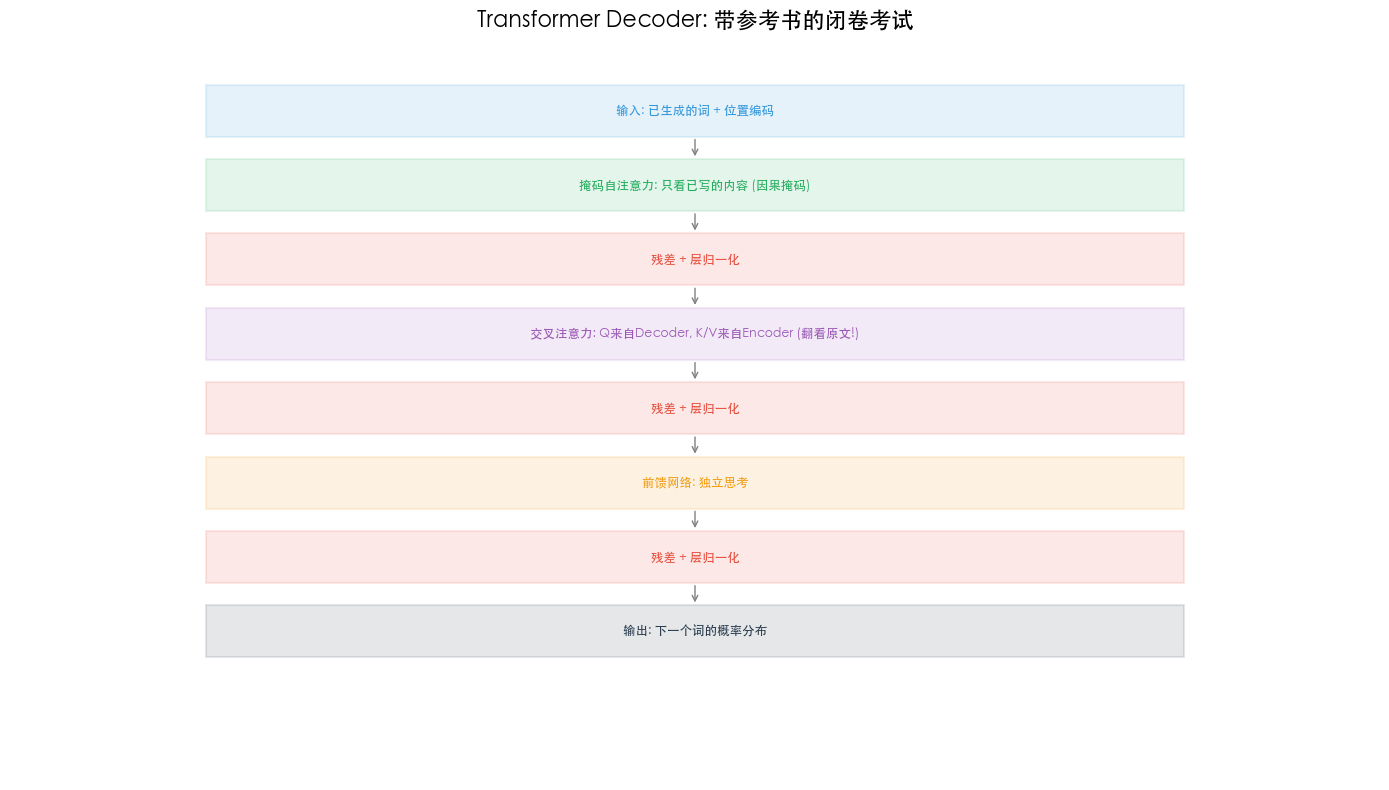</p>*Transformer Decoder 流程图*

## 3. 数学直觉：Decoder 的三个子层一个 Decoder 层包含三个子层：### 3.1 掩码自注意力$$\text{Sublayer}_1(x) = \text{LayerNorm}(x + \text{MaskedMultiHead}(x, x, x))$$- Q = K = V = x（自注意力）- **掩码**：每个位置只能看到自己和之前的位置，不能看到"未来"- 这保证了生成过程的自回归性质### 3.2 交叉注意力$$\text{Sublayer}_2(x) = \text{LayerNorm}(x + \text{MultiHead}(x, H_{enc}, H_{enc}))$$- Q 来自 Decoder（"我现在要翻译什么"）- K 和 V 来自 Encoder（"源句子有什么信息"）- 这就是 Decoder "回头看" Encoder 的方式### 3.3 前馈网络$$\text{Sublayer}_3(x) = \text{LayerNorm}(x + \text{FFN}(x))$$- 和 Encoder 一样的前馈网络---

## 4. 代码实验室：搭建 Decoder

In [ ]:
import torchimport torch.nn as nnimport torch.nn.functional as Fimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 4.1 因果掩码

In [ ]:
def create_causal_mask(seq_len):    mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()    return maskmask = create_causal_mask(6)print("因果掩码 (True = 被遮住):")print(mask.int().numpy())print()print("含义: 位置 i 只能看到位置 0~i")print("  位置0: 只看自己")print("  位置1: 看位置0和1")print("  位置5: 看位置0~5")

### 4.2 手写 Decoder 层

In [ ]:
class TransformerDecoderLayer(nn.Module):    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):        super().__init__()        self.n_heads = n_heads        self.d_k = d_model // n_heads        self.W_Q1 = nn.Linear(d_model, d_model)        self.W_K1 = nn.Linear(d_model, d_model)        self.W_V1 = nn.Linear(d_model, d_model)        self.W_O1 = nn.Linear(d_model, d_model)        self.W_Q2 = nn.Linear(d_model, d_model)        self.W_K2 = nn.Linear(d_model, d_model)        self.W_V2 = nn.Linear(d_model, d_model)        self.W_O2 = nn.Linear(d_model, d_model)        self.norm1 = nn.LayerNorm(d_model)        self.norm2 = nn.LayerNorm(d_model)        self.norm3 = nn.LayerNorm(d_model)        self.ffn = nn.Sequential(            nn.Linear(d_model, d_ff),            nn.ReLU(),            nn.Dropout(dropout),            nn.Linear(d_ff, d_model),            nn.Dropout(dropout)        )        self.dropout = nn.Dropout(dropout)    def masked_self_attention(self, x, mask=None):        B, S, D = x.shape        Q = self.W_Q1(x).view(B, S, self.n_heads, self.d_k).transpose(1, 2)        K = self.W_K1(x).view(B, S, self.n_heads, self.d_k).transpose(1, 2)        V = self.W_V1(x).view(B, S, self.n_heads, self.d_k).transpose(1, 2)        scores = Q @ K.transpose(-2, -1) / np.sqrt(self.d_k)        if mask is not None:            scores = scores.masked_fill(mask.unsqueeze(0).unsqueeze(0), float('-inf'))        attn = F.softmax(scores, dim=-1)        context = (attn @ V).transpose(1, 2).contiguous().view(B, S, D)        return self.W_O1(context), attn    def cross_attention(self, x, enc_output, mask=None):        B, S, D = x.shape        _, S_enc, _ = enc_output.shape        Q = self.W_Q2(x).view(B, S, self.n_heads, self.d_k).transpose(1, 2)        K = self.W_K2(enc_output).view(B, S_enc, self.n_heads, self.d_k).transpose(1, 2)        V = self.W_V2(enc_output).view(B, S_enc, self.n_heads, self.d_k).transpose(1, 2)        scores = Q @ K.transpose(-2, -1) / np.sqrt(self.d_k)        attn = F.softmax(scores, dim=-1)        context = (attn @ V).transpose(1, 2).contiguous().view(B, S, D)        return self.W_O2(context), attn    def forward(self, x, enc_output, causal_mask=None):        self_attn_out, self_attn = self.masked_self_attention(x, causal_mask)        x = self.norm1(x + self.dropout(self_attn_out))        cross_attn_out, cross_attn = self.cross_attention(x, enc_output)        x = self.norm2(x + self.dropout(cross_attn_out))        ffn_out = self.ffn(x)        x = self.norm3(x + ffn_out)        return x, self_attn, cross_attn

### 4.3 测试 Decoder

In [ ]:
d_model = 32n_heads = 4d_ff = 128decoder_layer = TransformerDecoderLayer(d_model, n_heads, d_ff)enc_output = torch.randn(2, 8, d_model)dec_input = torch.randn(2, 6, d_model)causal_mask = create_causal_mask(6)dec_output, self_attn, cross_attn = decoder_layer(dec_input, enc_output, causal_mask)print(f"Encoder 输出: {enc_output.shape}")print(f"Decoder 输入: {dec_input.shape}")print(f"Decoder 输出: {dec_output.shape}")print(f"自注意力权重: {self_attn.shape}")print(f"交叉注意力权重: {cross_attn.shape}")

### 4.4 可视化掩码效果

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))im = axes[0].imshow(causal_mask.numpy(), cmap='gray_r')axes[0].set_title('因果掩码 (黑=可见, 白=遮住)', fontsize=12)axes[0].set_xlabel('Key 位置')axes[0].set_ylabel('Query 位置')self_attn_vis = self_attn[0, 0].detach().numpy()im = axes[1].imshow(self_attn_vis, cmap='YlOrRd', vmin=0)axes[1].set_title('掩码自注意力 (下三角)', fontsize=12)axes[1].set_xlabel('Key 位置')axes[1].set_ylabel('Query 位置')plt.colorbar(im, ax=axes[1])cross_attn_vis = cross_attn[0, 0].detach().numpy()im = axes[2].imshow(cross_attn_vis, cmap='YlOrRd', vmin=0)axes[2].set_title('交叉注意力 (Decoder 看 Encoder)', fontsize=12)axes[2].set_xlabel('Encoder 位置')axes[2].set_ylabel('Decoder 位置')plt.colorbar(im, ax=axes[2])plt.tight_layout()plt.show()

---

## 今日结语今天我们搭建了 Transformer Decoder，它有三个关键子层：1. **掩码自注意力**：Decoder 只能看到已生成的词（因果掩码）2. **交叉注意力**：Decoder 动态查看 Encoder 的输出（Q 来自 Decoder，K/V 来自 Encoder）3. **前馈网络**：深入分析信息明天，我们将把 Encoder 和 Decoder 组合起来，搭建完整的 Transformer。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 不能偷看还没写到的答案 | 因果掩码——防止看到未来位置 || 翻译时翻看原文笔记 | 交叉注意力——Decoder 查看 Encoder || "我现在要翻译什么" | 交叉注意力的 Q 来自 Decoder || "源句子有什么信息" | 交叉注意力的 K/V 来自 Encoder || 自回归——一个一个生成 | 掩码自注意力——只能看到过去 |